# Ejercicio 8 — Incorporación de 2025 y evolución de tres años

Trabajo individual. Se valida la incorporación incremental de 2025, la preservación de 2024/2026 y las consultas sobre los tres años. Las interpretaciones usan meses comunes y poblaciones declaradas; 2026 incompleto no se equipara a un año entero.

Antes de ejecutar: snapshot previo, descarga inicial y repetida de 2024/2025/2026, y validación de 2024/2025 completos. El script de este notebook construye/reutiliza una instantánea identificada por sus fuentes sin sobrescribir las bases del benchmark. La instalación del tablero se realiza con la sesión local, fuera de este notebook.
Por defecto se revisan los resultados reales ya calculados. Active RUN_PIPELINE para repetir la construcción/validación completa; no se inventan ni estiman resultados.


In [1]:
from pathlib import Path
import os,sys,json
import pandas as pd
from IPython.display import display,Markdown,Image
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'scripts'/'complete_three_years.py').exists())
os.chdir(ROOT);sys.path.insert(0,str(ROOT/'scripts'))
from complete_three_years import complete
pd.set_option('display.max_columns',None);pd.set_option('display.max_rows',70)
RUN_PIPELINE=False
if RUN_PIPELINE:
    frames=complete()
else:
    result_dir=ROOT/'docs'/'resultados_ejercicio_8'
    if not (result_dir/'01_cobertura.csv').exists():
        raise FileNotFoundError('Primero ejecute complete_three_years.py o active RUN_PIPELINE.')
    frames={name:pd.read_csv(result_dir/(name+'.csv')) for name in ['01_cobertura','02_evolucion_mensual','03_periodo_comun','04_horas_por_anio']}

## 8.1–8.3 — Descarga, conservación y consultas

In [2]:
manifest=json.loads((ROOT/'data'/'processed'/'download_manifest_2024_2025_2026.json').read_text())
validation=json.loads((ROOT/'docs'/'validacion_descarga_2024_2025_2026.json').read_text())
preserved=json.loads((ROOT/'docs'/'resultados_ejercicio_8'/'preservacion.json').read_text())
print('Descarga repetida:',manifest['resumen'])
print('Parquet validados:',validation['archivos_validados'])
print('Archivos anteriores intactos:',len(preserved),all(r['sin_cambios'] for r in preserved))
display(frames['01_cobertura'])
display(pd.read_csv(ROOT/'docs'/'resultados_ejercicio_8'/'compatibilidad.csv'))

Descarga repetida: {'descargados': 0, 'omitidos': 64, 'no_publicados': ['yellow 2026-09', 'yellow 2026-10', 'yellow 2026-11', 'yellow 2026-12', 'green 2026-09', 'green 2026-10', 'green 2026-11', 'green 2026-12'], 'fallidos': []}
Parquet validados: 64
Archivos anteriores intactos: 40 True


,anio,tipo_taxi,archivos,meses,registros
0,2024,green,12,12,660218
1,2024,yellow,12,12,41169720
2,2025,green,12,12,591375
3,2025,yellow,12,12,48722602
4,2026,green,8,8,337114
5,2026,yellow,8,8,29703355


,consulta,estado,filas,anio
0,sql/exploracion/01_inventario.sql,OK,64,NaN
1,sql/exploracion/02_esquemas.sql,OK,1294,NaN
2,sql/exploracion/03_cambios_esquema.sql,OK,64,NaN
3,sql/exploracion/04_muestras.sql,OK,10,NaN
4,sql/exploracion/05_nulos.sql,OK,2,NaN
...,...,...,...,...
69,sql/indicadores/12_negativos.sql,OK,11,2026.0
70,sql/indicadores/13_cobertura.sql,OK,2,2026.0
71,sql/indicadores/14_demanda_comparable.sql,OK,6,2026.0
72,sql/indicadores/15_efectivo_comparable.sql,OK,6,2026.0


## 01_cobertura

Fuente: tabla de la instantánea validada de los tres años. La fecha de archivo determina año/mes; la población temporal excluye recogidas fuera del mes nominal.

In [3]:
print((ROOT/'sql'/'evolucion'/'01_cobertura.sql').read_text())
display(frames['01_cobertura'])

SELECT year(mes_archivo) AS anio,tipo_taxi,count(DISTINCT archivo) AS archivos,
 count(DISTINCT mes_archivo) AS meses,count(*) AS registros FROM viajes_duckdb
 GROUP BY anio,tipo_taxi ORDER BY anio,tipo_taxi;



,anio,tipo_taxi,archivos,meses,registros
0,2024,green,12,12,660218
1,2024,yellow,12,12,41169720
2,2025,green,12,12,591375
3,2025,yellow,12,12,48722602
4,2026,green,8,8,337114
5,2026,yellow,8,8,29703355


## 02_evolucion_mensual

Fuente: tabla de la instantánea validada de los tres años. La fecha de archivo determina año/mes; la población temporal excluye recogidas fuera del mes nominal.

In [4]:
print((ROOT/'sql'/'evolucion'/'02_evolucion_mensual.sql').read_text())
display(frames['02_evolucion_mensual'])

SELECT year(mes_archivo) AS anio,month(mes_archivo) AS mes,tipo_taxi,count(*) AS viajes,
 day(last_day(mes_archivo)) AS dias_calendario,
 count(*)::DOUBLE/day(last_day(mes_archivo)) AS viajes_por_dia
 FROM viajes_duckdb WHERE recogida>=mes_archivo AND recogida<mes_archivo+INTERVAL 1 MONTH
 GROUP BY anio,mes,tipo_taxi,mes_archivo ORDER BY tipo_taxi,anio,mes;



,anio,mes,tipo_taxi,viajes,dias_calendario,viajes_por_dia
0,2024,1,green,56549,31,1824.161290
1,2024,2,green,53571,29,1847.275862
2,2024,3,green,57447,31,1853.129032
3,2024,4,green,56467,30,1882.233333
4,2024,5,green,60994,31,1967.548387
5,2024,6,green,54735,30,1824.500000
6,2024,7,green,51811,31,1671.322581
7,2024,8,green,51751,31,1669.387097
8,2024,9,green,54406,30,1813.533333
9,2024,10,green,56140,31,1810.967742


## 03_periodo_comun

Fuente: tabla de la instantánea validada de los tres años. La fecha de archivo determina año/mes; la población temporal excluye recogidas fuera del mes nominal.

In [5]:
print((ROOT/'sql'/'evolucion'/'03_periodo_comun.sql').read_text())
display(frames['03_periodo_comun'])

-- Cobertura común en los tres años y ambos tipos. No equipara 12 meses con 8.
WITH cobertura AS (SELECT DISTINCT year(mes_archivo) AS anio,month(mes_archivo) AS mes,tipo_taxi FROM viajes_duckdb),
 comunes AS (SELECT mes FROM cobertura GROUP BY mes HAVING count(*)=6),
 datos AS NOT MATERIALIZED (SELECT *,year(mes_archivo) AS anio,date_diff('second',recogida,llegada)/60.0 AS duracion
 FROM viajes_duckdb WHERE month(mes_archivo) IN (SELECT mes FROM comunes)
 AND recogida>=mes_archivo AND recogida<mes_archivo+INTERVAL 1 MONTH),
 volumen AS (SELECT anio,tipo_taxi,count(*) AS viajes,
 100.0*count_if(payment_type=1)/count(*) AS porcentaje_tarjeta,
 100.0*count_if(payment_type=2)/count(*) AS porcentaje_efectivo,
 100.0*count_if(passenger_count IS NULL)/count(*) AS porcentaje_pasajeros_nulos,
 100.0*count_if(total_amount<0)/count(*) AS porcentaje_totales_negativos
 FROM datos GROUP BY anio,tipo_taxi),
 calendario AS (SELECT c.anio,c.tipo_taxi,sum(day(last_day(make_date(c.anio,c.mes,1)))) AS di

,anio,tipo_taxi,viajes,porcentaje_tarjeta,porcentaje_efectivo,porcentaje_pasajeros_nulos,porcentaje_totales_negativos,dias,viajes_por_dia,viajes_mediciones,distancia_mediana,duracion_mediana,total_mediano_usd
0,2024,green,443325,67.927141,27.176451,3.927593,0.348052,244.0,1816.905738,418618,1.959527,11.879630,19.110588
1,2025,green,397771,69.414814,22.642928,7.050791,0.306206,243.0,1636.917695,376633,2.028263,12.405821,19.817699
2,2026,green,337016,65.250018,19.554561,14.472607,0.303250,243.0,1386.897119,323668,2.146293,13.347262,20.574706
3,2024,yellow,26387932,74.052476,13.934317,9.525722,1.367091,244.0,108147.262295,25514075,1.796917,12.705868,20.942625
4,2025,yellow,31556277,63.807758,9.849780,23.271408,1.935285,243.0,129861.222222,28697626,1.873243,12.992688,21.645991
5,2026,yellow,29703209,63.767157,9.116884,25.979307,0.544830,243.0,122235.427984,28240105,1.934204,14.116176,23.591704


## 04_horas_por_anio

Fuente: tabla de la instantánea validada de los tres años. La fecha de archivo determina año/mes; la población temporal excluye recogidas fuera del mes nominal.

In [6]:
print((ROOT/'sql'/'evolucion'/'04_horas_por_anio.sql').read_text())
display(frames['04_horas_por_anio'])

SELECT year(mes_archivo) AS anio,tipo_taxi,hour(recogida) AS hora,count(*) AS viajes,
 100.0*count(*)/sum(count(*)) OVER(PARTITION BY year(mes_archivo),tipo_taxi) AS porcentaje
 FROM viajes_duckdb WHERE recogida>=mes_archivo AND recogida<mes_archivo+INTERVAL 1 MONTH
 GROUP BY anio,tipo_taxi,hora ORDER BY tipo_taxi,anio,hora;



,anio,tipo_taxi,hora,viajes,porcentaje
0,2024,green,0,12221,1.851515
1,2024,green,1,8496,1.287167
2,2024,green,2,6096,0.923561
3,2024,green,3,4628,0.701155
4,2024,green,4,4048,0.613283
...,...,...,...,...,...
139,2026,yellow,19,1840892,6.197620
140,2026,yellow,20,1699253,5.720772
141,2026,yellow,21,1759342,5.923070
142,2026,yellow,22,1632677,5.496635


## 8.4–8.5 — Actualización de indicadores y visualizaciones

La configuración del tablero apunta a la nueva instantánea; el instalador cambia la conexión DuckDB manteniendo el tablero y sus tarjetas. Los indicadores de demanda/costos/pagos de cada año se recalculan en carpetas separadas. Se añaden tres tarjetas comparativas que siempre consideran los tres años y no usan el filtro de año; sí aceptan tipo de taxi.

La comparación usa únicamente meses presentes en todos los años y ambos tipos. Se ajusta la demanda por días calendario y se conservan los filtros de medición del EDA. Los importes son nominales y las medianas aproximadas.

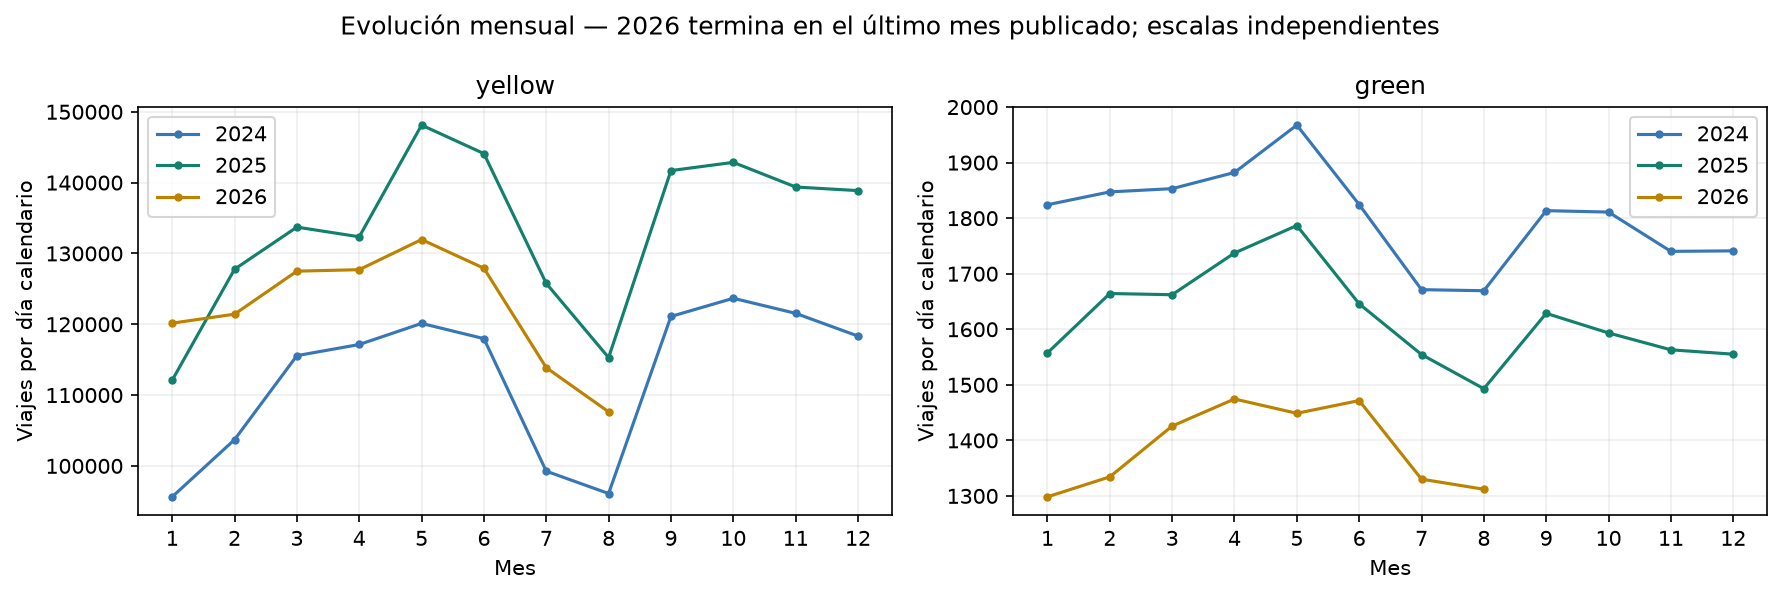

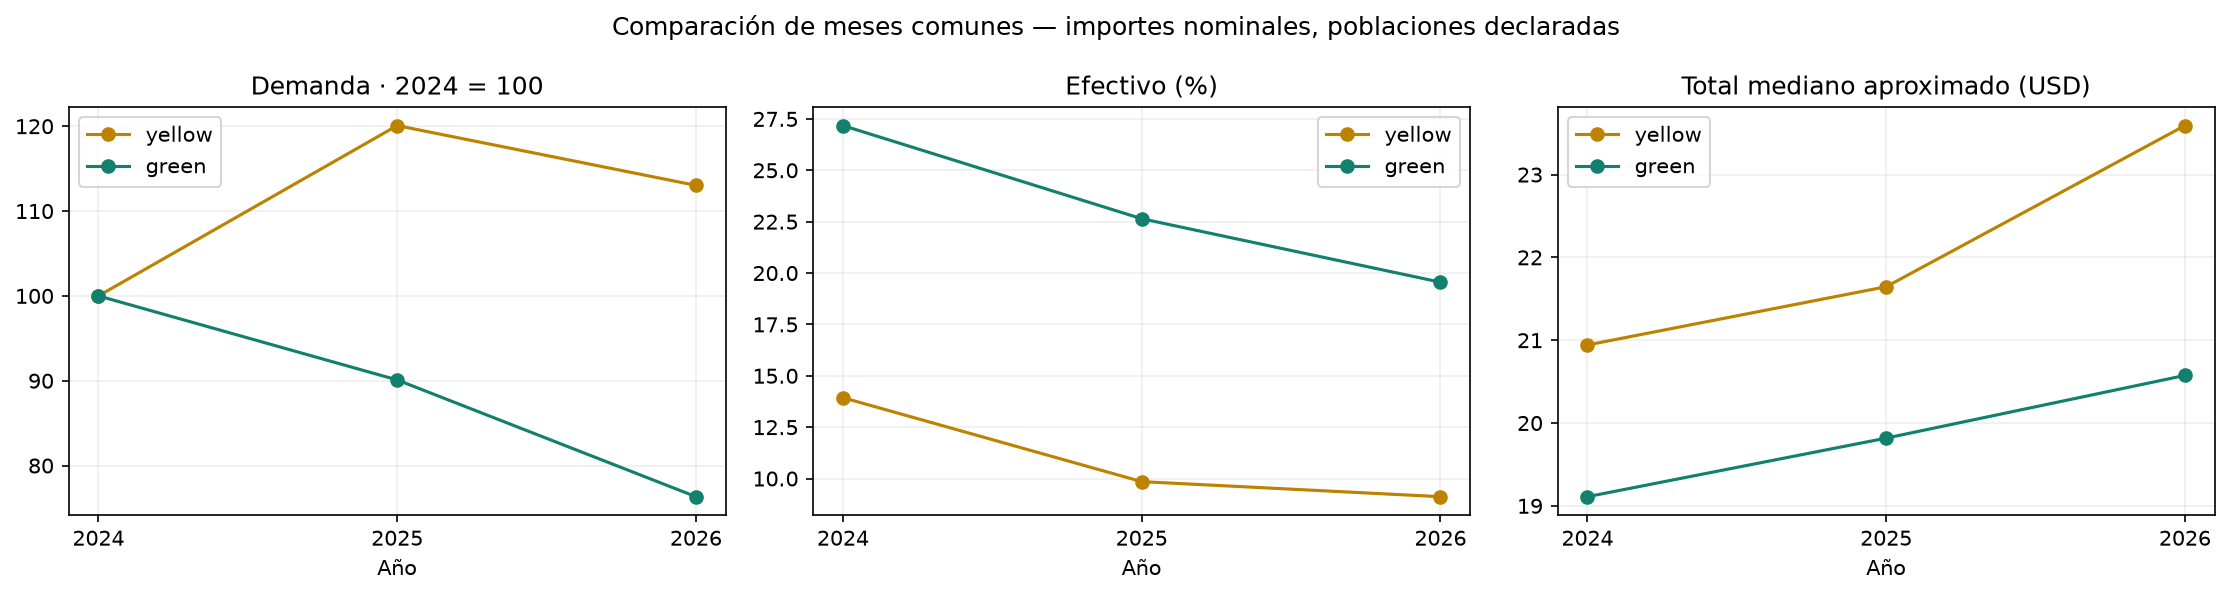

Indicadores recalculados: 2024 16
Indicadores recalculados: 2025 16
Indicadores recalculados: 2026 16


In [7]:
for filename in ['demanda_tres_anios.png','comparacion_periodo_comun.png']:
    display(Image(filename=str(ROOT/'docs'/'figuras_ejercicio_8'/filename)))
for year in [2024,2025,2026]:
    print('Indicadores recalculados:',year,len(list((ROOT/'docs'/'resultados_ejercicio_8'/f'indicadores_{year}').glob('*.csv'))))

## 8.6–8.7 — Cambios, patrones y consultas documentadas



1. **Demanda yellow:** viajes diarios del período común: 2024: 108,147.26, 2025: 129,861.22, 2026: 122,235.43. El cambio 2024→2026 es +13.03%. Se ajustan días calendario, incluido febrero bisiesto de 2024.

2. **Pago en efectivo yellow:** 13.93% en 2024, 9.85% en 2025 y 9.12% en 2026; cambio de -4.82 puntos porcentuales. No se reasignan pagos ausentes o Flex Fare.

3. **Cobertura de pasajeros yellow:** nulos 9.53% → 23.27% → 25.98%. Un cambio puede reflejar composición o registro; no prueba que haya viajes sin pasajeros.

4. **Total mediano yellow:** USD 20.94 → 21.65 → 23.59, en mediciones válidas. Es importe nominal, sin ajuste por inflación, rutas o cambios de cargos; no se atribuye causalidad.

5. **Demanda green:** viajes diarios del período común: 2024: 1,816.91, 2025: 1,636.92, 2026: 1,386.90. El cambio 2024→2026 es -23.67%. Se ajustan días calendario, incluido febrero bisiesto de 2024.

6. **Pago en efectivo green:** 27.18% en 2024, 22.64% en 2025 y 19.55% en 2026; cambio de -7.62 puntos porcentuales. No se reasignan pagos ausentes o Flex Fare.

7. **Cobertura de pasajeros green:** nulos 3.93% → 7.05% → 14.47%. Un cambio puede reflejar composición o registro; no prueba que haya viajes sin pasajeros.

8. **Total mediano green:** USD 19.11 → 19.82 → 20.57, en mediciones válidas. Es importe nominal, sin ajuste por inflación, rutas o cambios de cargos; no se atribuye causalidad.

Las variaciones de medianas son aproximadas. Los datos observados no identifican causalidad; composición de viajes, cobertura y registro pueden variar. Los importes no están ajustados por inflación y los meses de 2026 todavía no publicados no se tratan como cero.



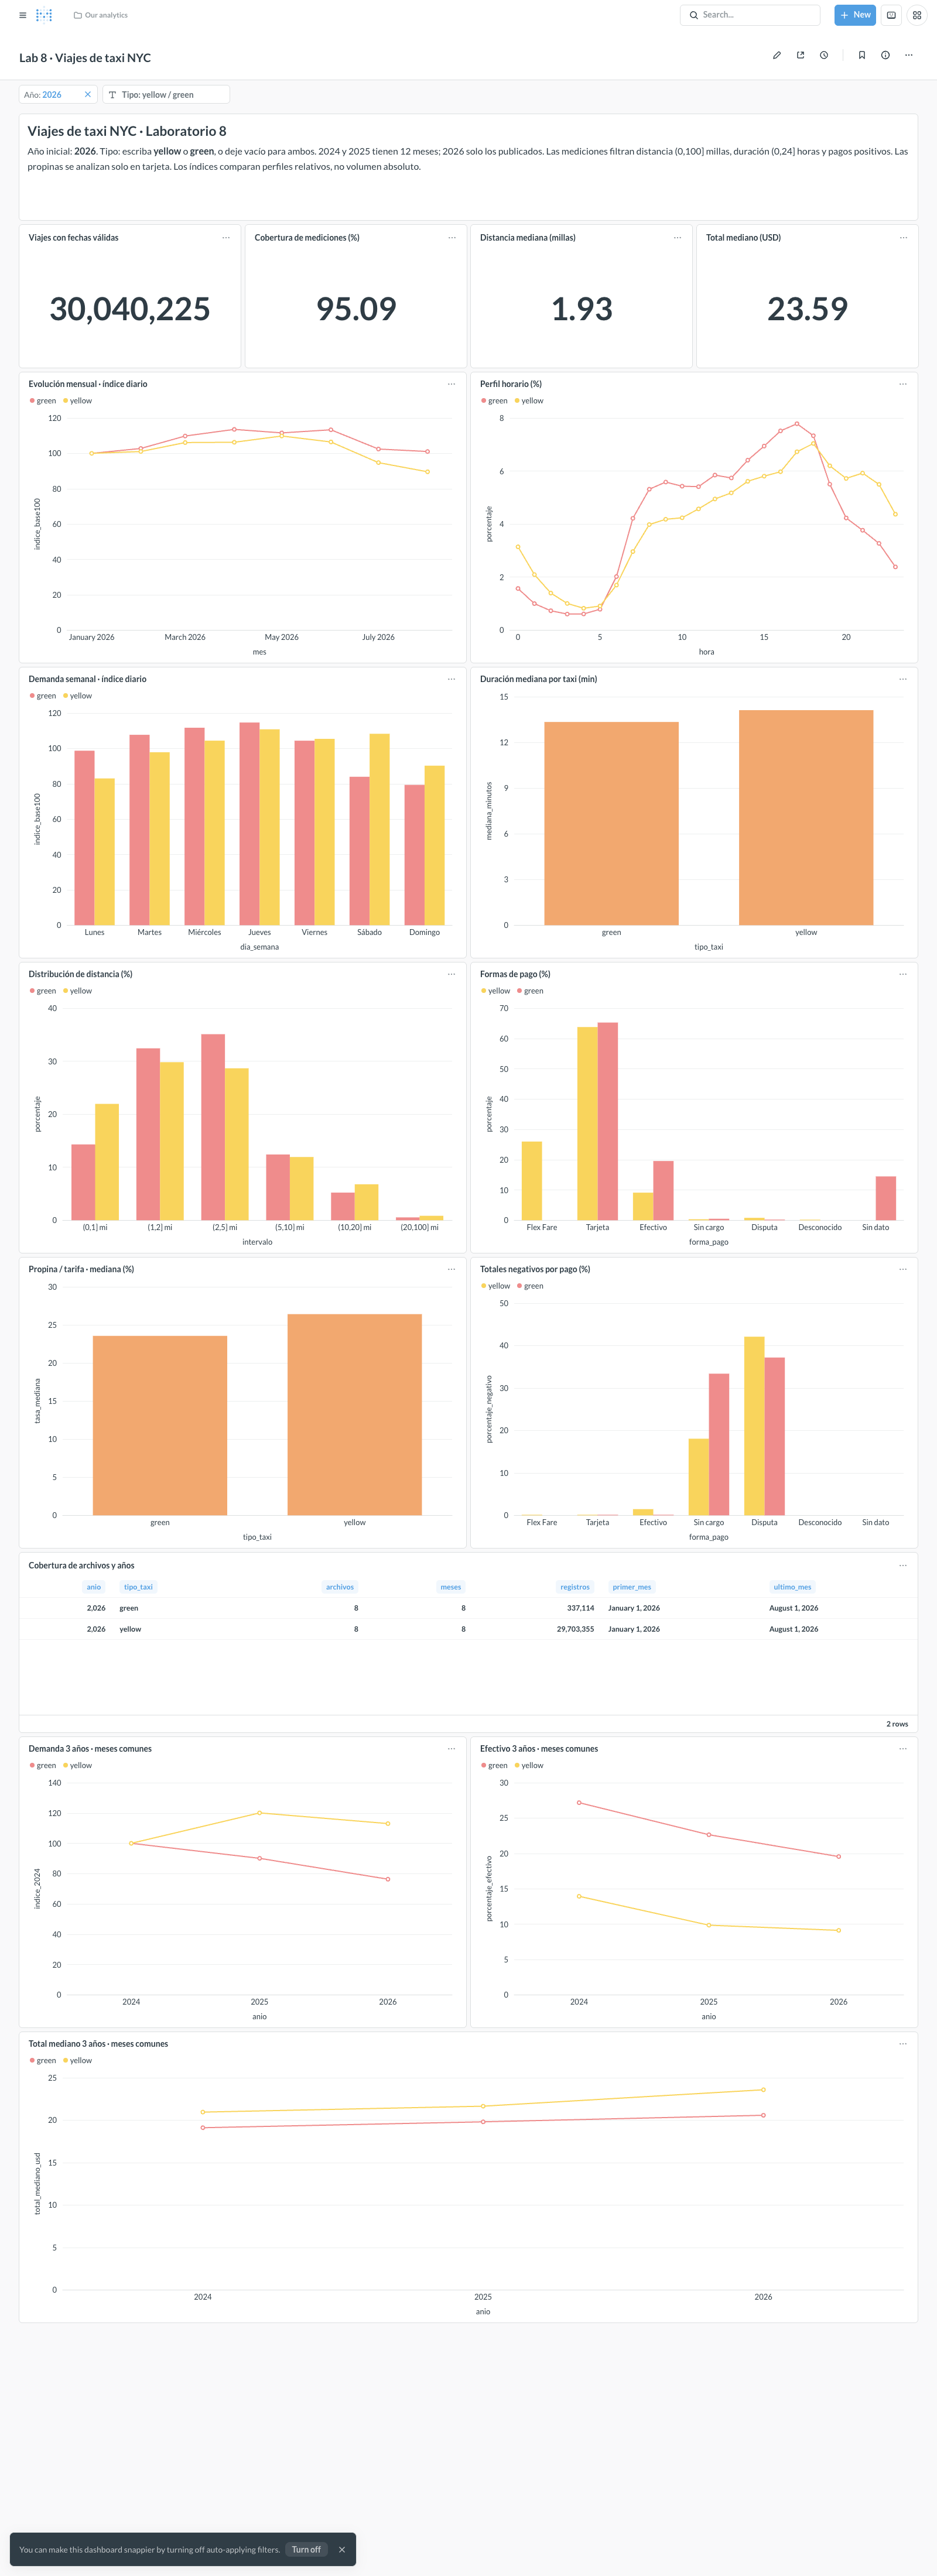

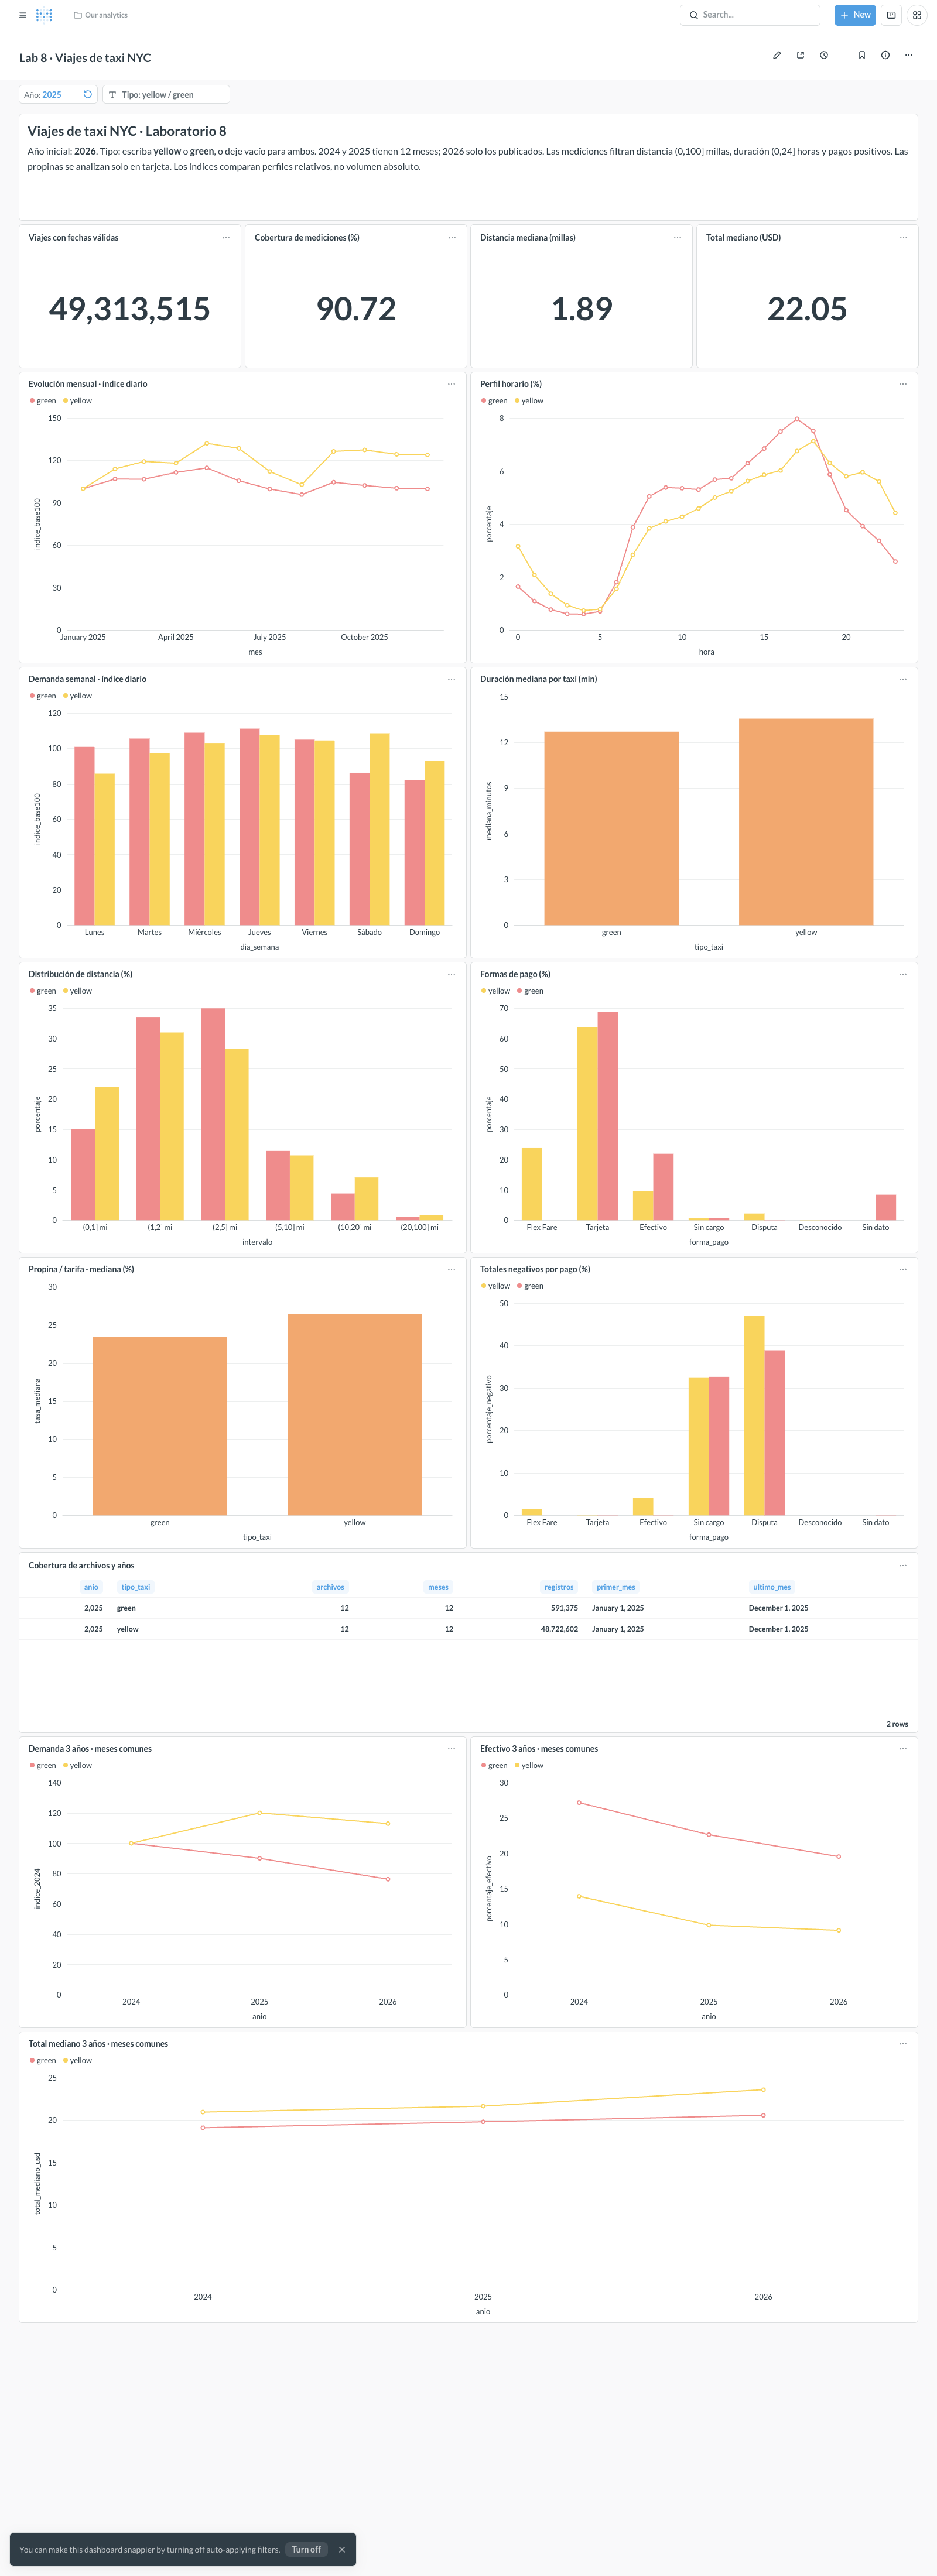

Documentación: docs/ejercicio_8_tres_anios.md


In [8]:
report=(ROOT/'docs'/'ejercicio_8_tres_anios.md').read_text()
display(Markdown(report.split('## Cambios y patrones (8.6)',1)[1].split('## Consultas documentadas',1)[0]))
for filename in ['tablero_tres_anios.png','tablero_2025.png']:
    path=ROOT/'docs'/'figuras_ejercicio_8'/filename
    if path.exists():display(Image(filename=str(path)))
print('Documentación: docs/ejercicio_8_tres_anios.md')

## Límites

Los cambios observados pueden reflejar composición de viajes, cobertura o registro. No identifican causalidad ni precios reales ajustados por inflación. Los meses no publicados no son cero viajes. Pasajeros nulos no significan viajes vacíos y pagos sin dato no se reclasifican a tarjeta/efectivo.

Los archivos originales y las credenciales permanecen excluidos de Git. Los resultados históricos del benchmark y la evidencia del ejercicio 7 se conservan por separado.